<a href="https://colab.research.google.com/github/Alina-Smol/portfolio_data_analyst/blob/main/%D0%BF%D0%BE%D1%80%D1%82%D1%84%D0%BE%D0%BB%D0%B8%D0%BE_%D1%82%D0%B0%D0%B1%D0%BB%D0%B8%D1%86%D0%B0_%D0%B7%D0%BF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# импорт необходимых библиотек
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# считываение данных из файлов
df_wage = pd.read_csv('wage.csv')
df_bonus = pd.read_csv('bonus.csv', sep = ';') #данные записаны в файле через точку с запятой
df_wage
# df_bonus

,person_id,gender,wage
0,0,1,46793.603811
1,1,1,33481.575720
2,2,1,44523.699084
3,3,1,15995.576829
4,4,0,10282.631224
...,...,...,...
1001,995,1,66503.737185
1002,996,1,9972.956272
1003,997,0,104504.616392
1004,998,1,98927.903076


In [5]:
gender_map = {1: 'female', 0: 'male'}
df_wage['gender'] = df_wage['gender'].map(gender_map)
# df_wage


In [6]:
# проверяем количество уникальных значений. вывод -> есть 6 неуникальных строчки
nunique_count = df_wage['person_id'].nunique()

# выводим какие именно строки повторяются и их количество
duplicates = df_wage['person_id'].value_counts()
print("\nКоличество вхождений person_id:\n", duplicates[duplicates > 1])
# удаляем дубликаты и сразу же проверяем уникальность строк
# Убедились, что записи по ним с одинаковым wage
# Если nunique() > 1, значит у одного человека разная зарплата в разных строках
wage_check = df_wage.groupby('person_id')['wage'].nunique()
wage_check[wage_check > 2]

wage = df_wage.drop_duplicates(subset=['person_id', 'wage'])
wage


Количество вхождений person_id:
 person_id
17    2
16    2
15    2
14    2
13    2
12    2
Name: count, dtype: int64


,person_id,gender,wage
0,0,female,46793.603811
1,1,female,33481.575720
2,2,female,44523.699084
3,3,female,15995.576829
4,4,male,10282.631224
...,...,...,...
1001,995,female,66503.737185
1002,996,female,9972.956272
1003,997,male,104504.616392
1004,998,female,98927.903076


In [7]:
wage.groupby('gender')['wage'].mean()

,wage
gender,
female,46531.457622
male,40811.235409


In [8]:
wage.describe()

,person_id,wage
count,1000.000000,1000.000000
mean,499.500000,43694.227404
std,288.819436,55352.539343
min,0.000000,-287418.645743
25%,249.750000,14489.682367
50%,499.500000,27309.529498
75%,749.250000,52021.080258
max,999.000000,755320.874132


In [9]:
# есть значения меньше 0, избавляемся от них
wage = wage[wage['wage'] > 0]
wage

,person_id,gender,wage
0,0,female,46793.603811
1,1,female,33481.575720
2,2,female,44523.699084
3,3,female,15995.576829
4,4,male,10282.631224
...,...,...,...
1001,995,female,66503.737185
1002,996,female,9972.956272
1003,997,male,104504.616392
1004,998,female,98927.903076


In [10]:
wage.groupby('gender')['wage'].mean()

,wage
gender,
female,47195.374328
male,41353.986687


In [11]:
# объединяем таблицы зарплат и бонусов
df = pd.merge(wage, df_bonus, on='person_id', how='outer')
df

,person_id,gender,wage,bonus
0,0,female,46793.603811,3.332934e+04
1,1,female,33481.575720,NaN
2,2,female,44523.699084,3.192912e+06
3,3,female,15995.576829,2.196858e+04
4,4,male,10282.631224,NaN
...,...,...,...,...
994,995,female,66503.737185,3.452137e+03
995,996,female,9972.956272,3.892790e+05
996,997,male,104504.616392,5.380978e+04
997,998,female,98927.903076,NaN


In [12]:
#  отсутствующие записи в колонке bonus заменяем нулями
df['bonus'] = df['bonus'].fillna(0)
df

,person_id,gender,wage,bonus
0,0,female,46793.603811,3.332934e+04
1,1,female,33481.575720,0.000000e+00
2,2,female,44523.699084,3.192912e+06
3,3,female,15995.576829,2.196858e+04
4,4,male,10282.631224,0.000000e+00
...,...,...,...,...
994,995,female,66503.737185,3.452137e+03
995,996,female,9972.956272,3.892790e+05
996,997,male,104504.616392,5.380978e+04
997,998,female,98927.903076,0.000000e+00


In [13]:
# убираем людей без wage (те, у кого оклад NaN после outer join)
df = df[df['wage'].notna()]
df

,person_id,gender,wage,bonus
0,0,female,46793.603811,3.332934e+04
1,1,female,33481.575720,0.000000e+00
2,2,female,44523.699084,3.192912e+06
3,3,female,15995.576829,2.196858e+04
4,4,male,10282.631224,0.000000e+00
...,...,...,...,...
994,995,female,66503.737185,3.452137e+03
995,996,female,9972.956272,3.892790e+05
996,997,male,104504.616392,5.380978e+04
997,998,female,98927.903076,0.000000e+00


In [14]:
# 12 окладов + премия
df['total'] = df['wage'] * 12 + df['bonus']

/tmp/ipykernel_21181/3187610906.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['total'] = df['wage'] * 12 + df['bonus']


In [15]:
# средняя и медианная итоговая зарплата по полу
stats = df.groupby('gender')['total'].agg(['mean', 'median'])
print("\nИтоговая статистика (total):\n", stats)


Итоговая статистика (total):
                  mean         median
gender                              
female  657142.490282  437499.824868
male    570746.139432  347622.913892


# **Графики на основе таблицы**

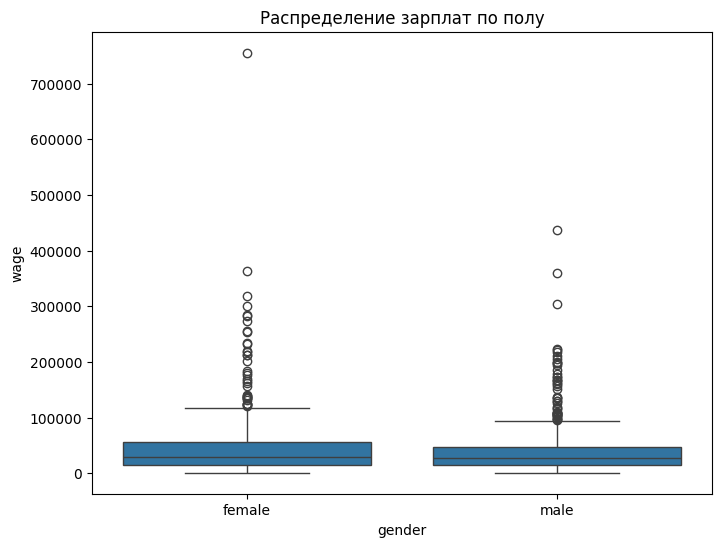

In [16]:
#распределение зарпла по полу
plt.figure(figsize=(8, 6))
sns.boxplot(x='gender', y='wage', data=df)
plt.title('Распределение зарплат по полу')
plt.show()


# 1. Медианные зарплаты похожи
# Медианыу мужчин и женщин находятся на примерно одинаковом уровне
# Это говорит об отсутствии явного гендерного разрыва
# 2. Много выбросов
# Очень много точек-выбросов выше основного распределения
# У женщин выбросы достигают 750,000 рублей
# У мужчин выбросы доходят до 400,000 рублей
# Это указывает на наличие высокооплачиваемых позиций в обеих группах
# 3. Межквартильный размах  схож
# Размеры ящиков (25-75 перцентили) примерно одинаковые
# Разброс "средних" зарплат сопоставим

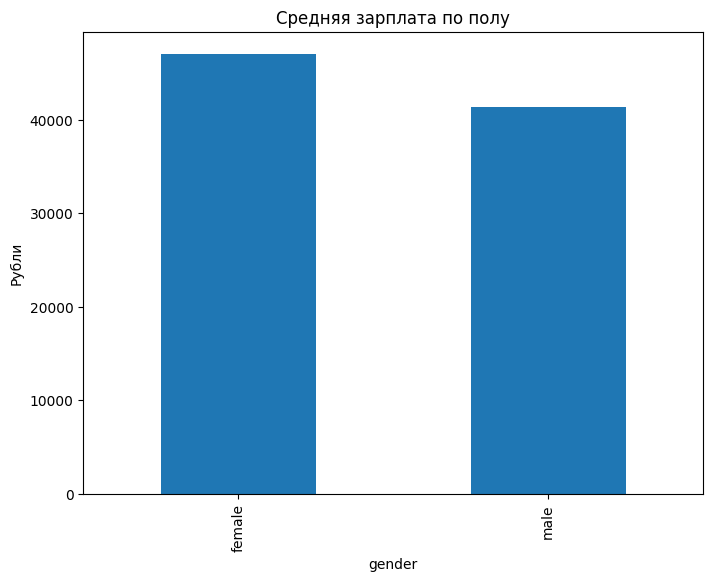

In [17]:
# Bar chart средних значений
plt.figure(figsize=(8, 6))
df.groupby('gender')['wage'].mean().plot(kind='bar')
plt.title('Средняя зарплата по полу')
plt.ylabel('Рубли')
plt.show()

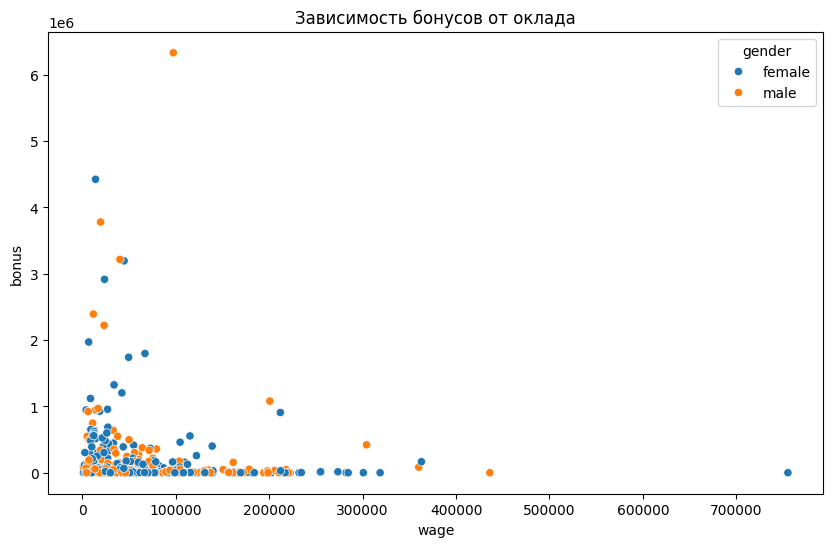

In [18]:
# Scatter plot: оклад vs бонус
plt.figure(figsize=(10, 6))
sns.scatterplot(x='wage', y='bonus', data=df, hue='gender')
plt.title('Зависимость бонусов от оклада')
plt.show()
# Отсутствует явная корреляция
# Между размером оклада и бонусом нет прямой зависимости
# Люди с высокими окладами (400k-700k) получают минимальные бонусы
# Самые высокие бонусы (до 6M+) получают сотрудники с относительно небольшими окладами (50-150k)

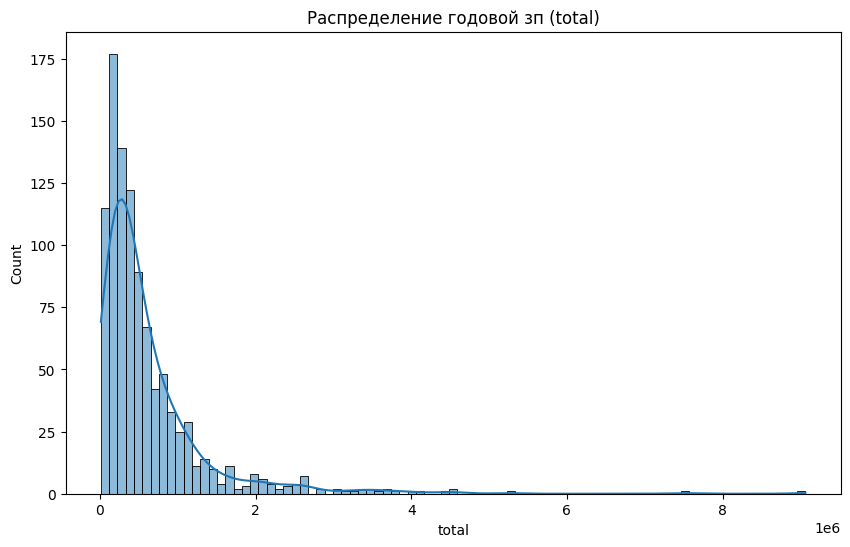

In [19]:
# Распределение итоговой зарплаты (total)
plt.figure(figsize=(10, 6))
sns.histplot(df['total'], kde=True)
plt.title('Распределение годовой зп (total)')
plt.show()

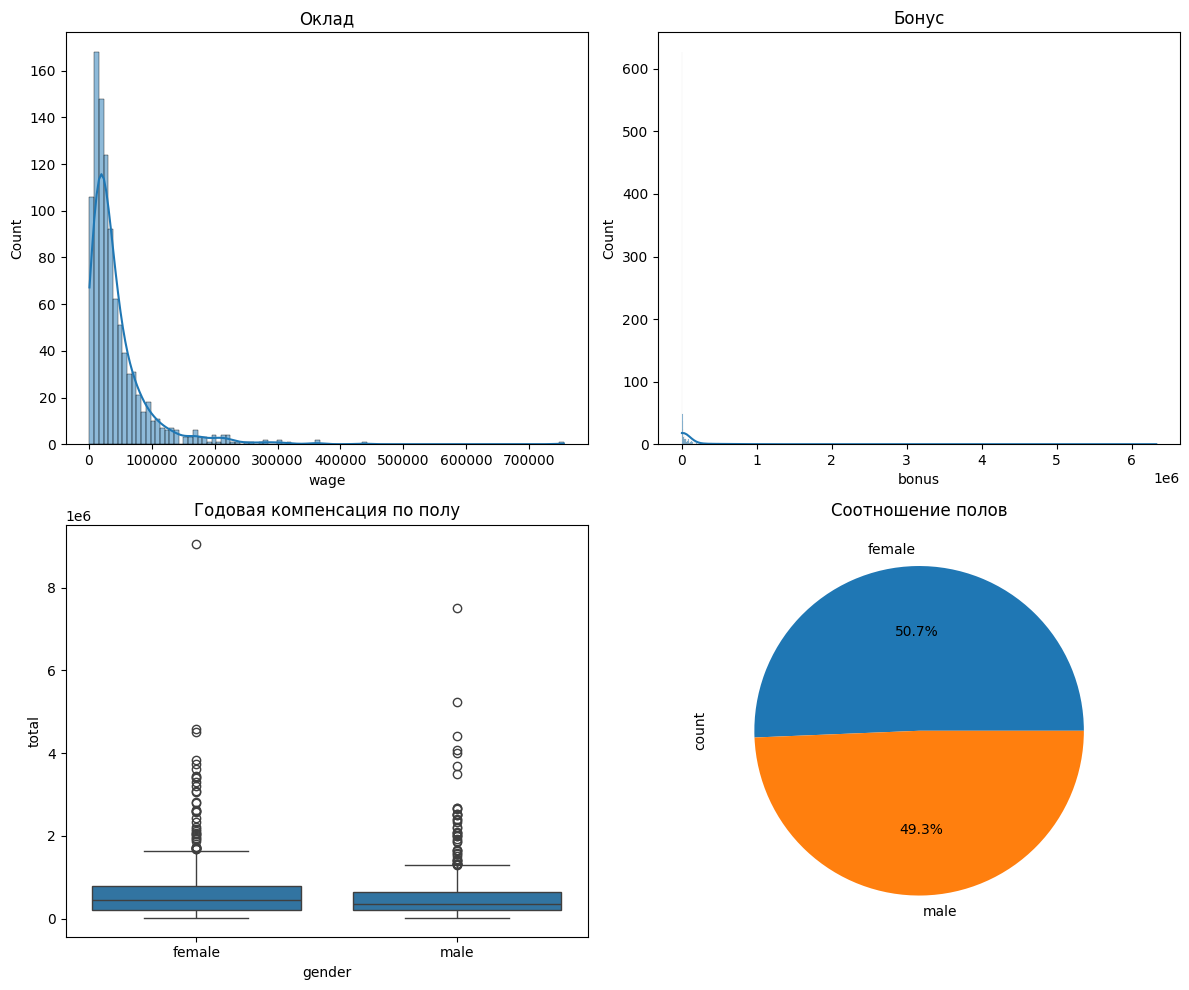

In [20]:
# Несколько графиков вместе
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.histplot(df['wage'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Оклад')

sns.histplot(df['bonus'], kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Бонус')

sns.boxplot(x='gender', y='total', data=df, ax=axes[1, 0])
axes[1, 0].set_title('Годовая компенсация по полу')

df['gender'].value_counts().plot(kind='pie', ax=axes[1, 1], autopct='%1.1f%%')
axes[1, 1].set_title('Соотношение полов')

plt.tight_layout()
plt.show()